# DataBento MBO: Order Flow Predictability

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Quantify whether one-minute order-flow imbalance carries predictive
information for next-minute returns on NVDA, and contrast midprice
markouts with executable (bid/ask-at-decision-time) markouts to expose
the gap §3.3 warns about between statistical signal and trading P&L.

## Learning Objectives

After completing this notebook, you will be able to:
- Build minute-resolution OFI from the LOB-reconstruction parquet that
  `08_databento_lob_reconstruction` writes.
- Measure predictability at multiple horizons (1, 5, 10, 30 min) and
  recognize that the correlations are tiny and noisy on a sample of this
  length.
- Distinguish midprice markouts from executable markouts and explain why
  spread and queue dynamics dominate P&L at sub-minute horizons.

## Book reference

Section §3.3, *From Raw Messages to the Limit Order Book* — tradability
caveat under "LOB Stylized Facts: Predictive Patterns".

## Prerequisites

- DataBento XNAS-ITCH MBO parquets at
  `data/equities/market/microstructure/market_by_order/NVDA/` (10 trading
  days, November 2024).

## Data Source

DataBento provides institutional-quality **Market-by-Order (MBO)** data:
- Every order add, cancel, modify, and fill
- Nanosecond timestamps (both exchange and receipt time)
- Pre-filtered by symbol (no ITCH stock_locate mapping needed)

---

## Setup

In [1]:
"""DataBento MBO: Order Flow Predictability — analyzing OFI signals in tick data."""

import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from tqdm.auto import tqdm

from data import load_mbo_data
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds

In [2]:
MAX_SYMBOLS = 0  # 0 = all
SEED = 42

In [3]:
set_global_seeds(SEED)
sns.set_style("whitegrid")

# ML4T Blue Period palette
COLORS = {
    "blue": "#1E3A5F",
    "accent": "#4A90A4",
    "warm": "#8B4513",
    "neutral": "#5D5D5D",
}

In [4]:
OUTPUT_DIR = get_output_dir(3, "databento")

SYMBOL = "NVDA"

# Get file paths from canonical loader
data_files = load_mbo_data(symbols=[SYMBOL], list_files=True)
SYMBOL_DIR = data_files[0].parent if data_files else None

# Production: use all files; testing: limit
MAX_FILES = None
MAX_ROWS = None

if SYMBOL_DIR and SYMBOL_DIR.exists():
    data_files = sorted(SYMBOL_DIR.glob("*.parquet"))
    if MAX_FILES:
        data_files = data_files[:MAX_FILES]
    print(f"Symbol: {SYMBOL}")
    print(f"Data files: {len(data_files)} days")
    if data_files:
        dates = [f.stem.split("-")[-1].split(".")[0] for f in data_files]
        print(f"Date range: {dates[0]} to {dates[-1]}")
else:
    print(f"DataBento data not found at {SYMBOL_DIR}")
    data_files = []

Symbol: NVDA
Data files: 10 days
Date range: 20241104 to 20241115


## 1. Understanding MBO Data

Market-by-Order data captures every change to the order book:

| Action | Meaning | Order Flow Signal |
|--------|---------|-------------------|
| **Add (A)** | New limit order placed | Passive liquidity supply |
| **Cancel (C)** | Order withdrawn | Liquidity withdrawal |
| **Fill (F)** | Order executed | Active demand/supply |
| **Trade (T)** | Trade report | Price discovery |

The **side** field tells us whether the order was on the bid (buy) or ask (sell).
Combining action and side reveals the order flow dynamics.

In [5]:
ACTION_MAP = {"A": "Add", "C": "Cancel", "F": "Fill", "M": "Modify", "R": "Clear", "T": "Trade"}
SIDE_MAP = {"A": "Ask", "B": "Bid", "N": "None"}


def load_databento_day(file_path: Path, max_rows: int | None = None) -> pl.DataFrame:
    """Load one day of DataBento MBO data."""
    df = pl.read_parquet(file_path)
    if max_rows and len(df) > max_rows:
        df = df.head(max_rows)

    # Handle fixed-point prices if needed
    if "price" in df.columns and df["price"].max() > 1_000_000:
        df = df.with_columns((pl.col("price") / 1e9).alias("price"))

    return df.with_columns(pl.col("timestamp").cast(pl.Datetime("ns")))

In [6]:
sample_df = None
multi_day = None

if data_files:
    sample_df = load_databento_day(data_files[0], max_rows=MAX_ROWS)
    date_str = data_files[0].stem.split("-")[-1].split(".")[0]

    print(f"=== {SYMBOL} on {date_str} ===")
    print(f"Total messages: {len(sample_df):,}")

    # Message composition
    print("\nMessage composition:")
    action_counts = sample_df.group_by("action").len().sort("len", descending=True)
    total = len(sample_df)
    for row in action_counts.iter_rows():
        pct = 100 * row[1] / total
        print(f"  {ACTION_MAP.get(row[0], row[0]):8s} {row[1]:>12,} ({pct:5.1f}%)")

=== NVDA on 20241104 ===
Total messages: 9,168,110

Message composition:


  Cancel      4,409,328 ( 48.1%)
  Add         4,368,340 ( 47.6%)
  Trade         213,835 (  2.3%)
  Fill          176,606 (  1.9%)
  Clear               1 (  0.0%)


**What this tells us**: Adds and cancels dominate (~48% each), with trades
comprising only ~2% of messages. This ~40:1 ratio of quote changes to trades
is typical for liquid stocks—the order book is constantly reshaping itself
around each trade.

## 2. Book Pressure: Measuring Order Flow Momentum

The core idea is simple: when buyers are more aggressive than sellers,
prices should rise. We measure this by tracking the net flow of orders:

**Book Pressure** = Σ (sign × weight × size × decay)

Where:
- **sign**: +1 for bids, -1 for asks
- **weight**: +1 for adds, -1 for cancels, +0.5 for fills
- **decay**: exp(-λ × distance_from_mid) — orders near the spread matter more

This creates a momentum indicator: positive pressure suggests buying interest,
negative suggests selling.

In [7]:
def compute_book_pressure(
    df: pl.DataFrame,
    decay_lambda: float = 0.01,
    ema_halflife: int = 100,
) -> pl.DataFrame:
    """Compute book pressure from MBO messages with EMA smoothing."""
    book_actions = df.filter(pl.col("action").is_in(["A", "C", "F"]))
    if len(book_actions) == 0:
        return df.with_columns(pl.lit(0.0).alias("book_pressure"))

    # Rolling midprice from recent trades (avoids lookahead)
    trades = df.filter(pl.col("action") == "T").select(["timestamp", "price"])

    if len(trades) > 0:
        rolling_mid = trades.with_columns(
            pl.col("price").rolling_mean(window_size=100, min_periods=1).alias("mid_price")
        ).select(["timestamp", "mid_price"])

        df = df.sort("timestamp").join_asof(
            rolling_mid.sort("timestamp"), on="timestamp", strategy="backward"
        )
        df = df.with_columns(pl.col("mid_price").fill_null(rolling_mid["mid_price"][0]))
    else:
        df = df.with_columns(pl.lit(book_actions["price"].median()).alias("mid_price"))

    # Compute pressure components
    result = (
        df.with_columns(
            [
                pl.when(pl.col("side") == "B")
                .then(1.0)
                .when(pl.col("side") == "A")
                .then(-1.0)
                .otherwise(0.0)
                .alias("side_sign"),
                pl.when(pl.col("action") == "A")
                .then(1.0)
                .when(pl.col("action") == "C")
                .then(-1.0)
                .when(pl.col("action") == "F")
                .then(0.5)
                .otherwise(0.0)
                .alias("action_weight"),
                (pl.col("price") - pl.col("mid_price")).abs().alias("dist_from_mid"),
            ]
        )
        .with_columns((-decay_lambda * pl.col("dist_from_mid")).exp().alias("decay_weight"))
        .with_columns(
            (
                pl.col("side_sign")
                * pl.col("action_weight")
                * pl.col("size")
                * pl.col("decay_weight")
            ).alias("raw_pressure")
        )
        .with_columns(
            pl.col("raw_pressure").ewm_mean(half_life=ema_halflife).alias("book_pressure")
        )
    )

    return result.select(
        ["timestamp", "action", "side", "price", "size", "order_id", "book_pressure"]
    )

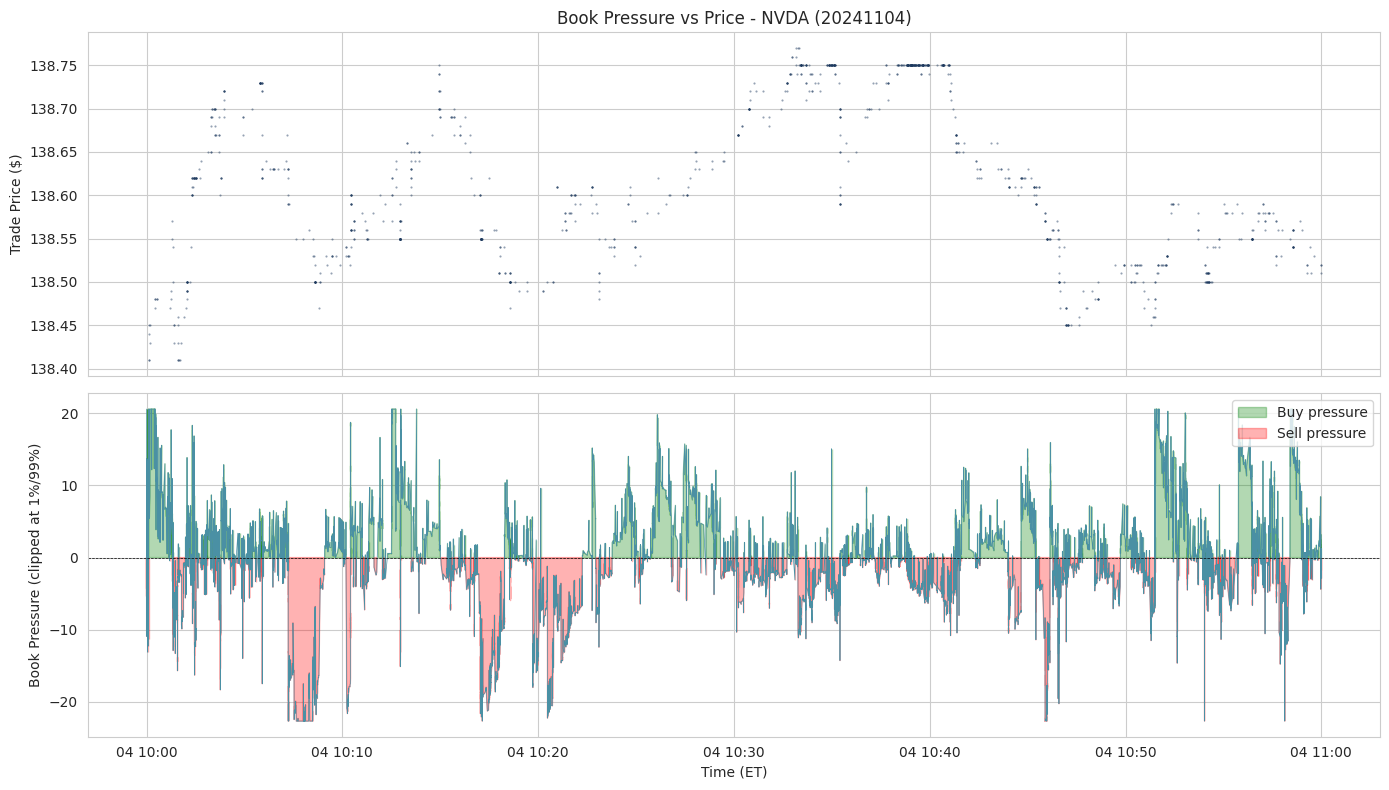

=== Book Pressure Statistics ===
Mean:          -0.57
Std:            9.51
Skewness:      18.60


In [8]:
# Single cell: build the two-panel figure (price + book pressure) end-to-end
# so papermill emits both panels populated. Splitting price and pressure into
# separate cells leaves the second panel empty in the rendered .ipynb.
pressure_df = None
if sample_df is not None and len(sample_df) > 0:
    # One hour of data (10:00-11:00 is typically liquid)
    sample_hour = sample_df.filter(
        (pl.col("timestamp").dt.hour() >= 10) & (pl.col("timestamp").dt.hour() < 11)
    )

    if len(sample_hour) > 1000:
        pressure_df = compute_book_pressure(sample_hour)

        fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

        # Top: trade prices
        trades = pressure_df.filter(pl.col("action") == "T").to_pandas()
        if len(trades) > 0:
            axes[0].plot(
                trades["timestamp"],
                trades["price"],
                ".",
                markersize=1,
                alpha=0.5,
                color=COLORS["blue"],
            )
            axes[0].set_ylabel("Trade Price ($)")
            axes[0].set_title(f"Book Pressure vs Price - {SYMBOL} ({date_str})")

        # Bottom: book pressure (clipped for readability)
        pressure_pd = pressure_df.to_pandas()
        pressure_clipped = pressure_pd["book_pressure"].clip(
            lower=pressure_pd["book_pressure"].quantile(0.01),
            upper=pressure_pd["book_pressure"].quantile(0.99),
        )
        axes[1].plot(
            pressure_pd["timestamp"], pressure_clipped, linewidth=0.5, color=COLORS["accent"]
        )
        axes[1].axhline(0, color="black", linestyle="--", linewidth=0.5)
        axes[1].set_ylabel("Book Pressure (clipped at 1%/99%)")
        axes[1].set_xlabel("Time (ET)")
        axes[1].fill_between(
            pressure_pd["timestamp"],
            pressure_clipped,
            0,
            where=pressure_clipped > 0,
            alpha=0.3,
            color="green",
            label="Buy pressure",
        )
        axes[1].fill_between(
            pressure_pd["timestamp"],
            pressure_clipped,
            0,
            where=pressure_clipped < 0,
            alpha=0.3,
            color="red",
            label="Sell pressure",
        )
        axes[1].legend(loc="upper right")

        plt.tight_layout()
        plt.show()

        # Statistics
        print("=== Book Pressure Statistics ===")
        print(f"Mean:     {pressure_pd['book_pressure'].mean():>10.2f}")
        print(f"Std:      {pressure_pd['book_pressure'].std():>10.2f}")
        print(f"Skewness: {pressure_pd['book_pressure'].skew():>10.2f}")

**What the chart reveals**:

The book pressure oscillates around zero, with occasional sustained moves
that often precede price changes. Notice how:

- **Green zones** (positive pressure) tend to occur before price upticks
- **Red zones** (negative pressure) tend to precede price drops
- The signal is noisy—individual spikes aren't reliable, but trends are

This is the fundamental insight: order flow contains information about
short-term price direction, but the signal-to-noise ratio is low.

## 3. Building Minute Bars with Microstructure Features

Tick data is too noisy for most analysis. We aggregate to minute bars while
preserving the microstructure information that matters for prediction.

In [9]:
def reconstruct_bbo_bars(df: pl.DataFrame, bar_freq: str = "1m") -> pl.DataFrame:
    """Reconstruct the best bid/offer from the MBO stream and snapshot it per bar.

    A markout that reflects *tradable* P&L needs the quotes a marketable order
    would actually hit — the best bid and best ask at decision time — not a
    trade-price proxy. We replay the order stream to maintain top of book
    (resting size by price on each side), then take the last quote in each bar.

    Add (A) inserts resting size; Cancel (C) removes it; Fill (F) reduces it;
    Modify (M) re-prices an order; Clear (R) wipes the side. We key on
    ``order_id`` so cancels, fills, and modifies adjust the level the order
    actually rested on.
    """
    orders: dict[int, tuple[str, float, int]] = {}  # order_id -> (side, price, size)
    bids: dict[float, int] = {}  # price -> resting size
    asks: dict[float, int] = {}  # price -> resting size
    # Track the inside quote incrementally so we never scan the whole book per
    # message. Recomputing max(bids)/min(asks) on every one of tens of millions
    # of MBO messages is the bottleneck on multi-day streams; here the O(levels)
    # scan only fires when the prevailing best level itself empties.
    best_bid: float | None = None
    best_ask: float | None = None

    def _book(side: str) -> dict[float, int]:
        return bids if side == "B" else asks

    def _add(side: str, price: float, size: int) -> None:
        nonlocal best_bid, best_ask
        book = _book(side)
        book[price] = book.get(price, 0) + size
        if side == "B":
            if best_bid is None or price > best_bid:
                best_bid = price
        elif best_ask is None or price < best_ask:
            best_ask = price

    def _reduce(side: str, price: float, size: int) -> None:
        nonlocal best_bid, best_ask
        book = _book(side)
        if price in book:
            book[price] -= size
            if book[price] <= 0:
                del book[price]
                # Only when the inside level vacates do we rescan that side.
                if side == "B" and price == best_bid:
                    best_bid = max(bids) if bids else None
                elif side == "A" and price == best_ask:
                    best_ask = min(asks) if asks else None

    ts_out: list = []
    bid_out: list[float | None] = []
    ask_out: list[float | None] = []

    for ts, action, side, price, size, oid in (
        df.sort("timestamp")
        .select(["timestamp", "action", "side", "price", "size", "order_id"])
        .iter_rows()
    ):
        if action == "A" and side in ("B", "A"):
            orders[oid] = (side, price, size)
            _add(side, price, size)
        elif action == "C":
            if oid in orders:
                s, p, sz = orders.pop(oid)
                _reduce(s, p, sz)
            elif side in ("B", "A"):
                _reduce(side, price, size)
        elif action == "F":
            if oid in orders:
                s, p, sz = orders[oid]
                _reduce(s, p, size)
                if sz - size > 0:
                    orders[oid] = (s, p, sz - size)
                else:
                    orders.pop(oid, None)
            elif side in ("B", "A"):
                _reduce(side, price, size)
        elif action == "M":
            if oid in orders:
                s, p, sz = orders.pop(oid)
                _reduce(s, p, sz)
            if side in ("B", "A"):
                orders[oid] = (side, price, size)
                _add(side, price, size)
        elif action == "R":
            orders.clear()
            bids.clear()
            asks.clear()
            best_bid = best_ask = None
        # Trade (T) prints do not change the book; the matching Fill (F) does.

        ts_out.append(ts)
        bid_out.append(best_bid)
        ask_out.append(best_ask)

    bbo = pl.DataFrame(
        {"timestamp": ts_out, "best_bid": bid_out, "best_ask": ask_out},
        schema={"timestamp": pl.Datetime("ns"), "best_bid": pl.Float64, "best_ask": pl.Float64},
    )
    # Snapshot the quote prevailing at each bar close (last update within the bar).
    return bbo.group_by_dynamic("timestamp", every=bar_freq, period=bar_freq).agg(
        pl.col("best_bid").last(), pl.col("best_ask").last()
    )

In [10]:
def process_day_to_bars(
    file_path: Path, bar_freq: str = "1m", max_rows: int | None = None
) -> pl.DataFrame:
    """Process one day to minute bars with OHLCV and order flow metrics."""
    df = load_databento_day(file_path, max_rows=max_rows)

    # Reconstruct top of book from the full stream (orders resting before the
    # open carry into the session), then restrict bars to regular trading hours.
    bbo_bars = reconstruct_bbo_bars(df, bar_freq=bar_freq)

    # Regular trading hours (UTC: 13:30-21:00 covers both EST and EDT)
    df = df.filter(
        (
            (pl.col("timestamp").dt.hour() > 13)
            | ((pl.col("timestamp").dt.hour() == 13) & (pl.col("timestamp").dt.minute() >= 30))
        )
        & (pl.col("timestamp").dt.hour() < 21)
    )

    if len(df) == 0:
        return pl.DataFrame()

    trades = df.filter(pl.col("action") == "T")
    if len(trades) == 0:
        return pl.DataFrame()

    # Aggregate to bars
    bars = trades.group_by_dynamic("timestamp", every=bar_freq, period=bar_freq).agg(
        [
            pl.col("price").first().alias("open"),
            pl.col("price").max().alias("high"),
            pl.col("price").min().alias("low"),
            pl.col("price").last().alias("close"),
            pl.col("size").sum().alias("volume"),
            pl.len().alias("trade_count"),
            (pl.when(pl.col("side") == "B").then(pl.col("size")).otherwise(0))
            .sum()
            .alias("buy_volume"),
            (pl.when(pl.col("side") == "A").then(pl.col("size")).otherwise(0))
            .sum()
            .alias("sell_volume"),
            (pl.col("price") * pl.col("size")).sum().alias("notional"),
        ]
    )

    # Derived features
    bars = bars.with_columns(
        [
            ((pl.col("high") + pl.col("low")) / 2).alias("mid_price"),
            (pl.col("close") / pl.col("open") - 1).alias("return"),
            pl.when(pl.col("buy_volume") + pl.col("sell_volume") > 0)
            .then(
                (pl.col("buy_volume") - pl.col("sell_volume"))
                / (pl.col("buy_volume") + pl.col("sell_volume"))
            )
            .otherwise(0.0)
            .alias("ofi"),
            (pl.col("notional") / pl.col("volume")).alias("vwap"),
        ]
    )

    # Attach the reconstructed quote prevailing at each bar close. ``mid_quote``
    # is the true (bid+ask)/2 midpoint; the trade-derived ``mid_price`` above is
    # only a proxy. Keeping both lets us separate the price-response signal
    # (midpoint markout) from the spread a real order pays (executable markout).
    bars = bars.join(bbo_bars, on="timestamp", how="left")
    bars = bars.with_columns(((pl.col("best_bid") + pl.col("best_ask")) / 2).alias("mid_quote"))

    return bars

In [11]:
if data_files:
    all_bars = []
    n_days = MAX_FILES or len(data_files)
    for file in tqdm(data_files[:n_days], desc="Processing days"):
        bars = process_day_to_bars(file, max_rows=MAX_ROWS)
        if len(bars) > 0:
            all_bars.append(bars)

    if all_bars:
        multi_day = pl.concat(all_bars).sort("timestamp")
        print("\n=== Multi-Day Dataset ===")
        print(f"Minute bars: {len(multi_day):,}")
        print(f"Trading days: {multi_day['timestamp'].dt.date().n_unique()}")
        print(
            f"Date range: {multi_day['timestamp'].min().date()} to {multi_day['timestamp'].max().date()}"
        )

Processing days:   0%|          | 0/10 [00:00<?, ?it/s]


=== Multi-Day Dataset ===
Minute bars: 4,500
Trading days: 10
Date range: 2024-11-04 to 2024-11-15


## 4. The Key Question: Does OFI Predict Returns?

Order Flow Imbalance (OFI) measures the balance between buyer and seller
aggression in each minute:

**OFI = (Buy Volume - Sell Volume) / Total Volume**

Values range from -1 (all selling) to +1 (all buying). If markets are
efficient, OFI should predict short-term returns—aggressive buyers push
prices up, aggressive sellers push prices down.

But how strong is this relationship, and how long does it last?

In [12]:
# Latency in bars between signal time and earliest fillable execution.
# Defined once so the markout call and the downstream "h == LATENCY_BARS"
# guard in the plotting cell cannot drift apart.
LATENCY_BARS = 1


def compute_markouts(
    bars: pl.DataFrame, horizons: list | None = None, latency_bars: int = LATENCY_BARS
) -> pl.DataFrame:
    """Compute forward returns at multiple horizons within each trading session."""
    if horizons is None:
        horizons = [1, 5, 10, 30]

    result = bars.clone().with_columns(pl.col("timestamp").dt.date().alias("session_date"))

    for h in horizons:
        # Standard markout: price change from now to h minutes ahead
        result = result.with_columns(
            (pl.col("mid_price").shift(-h).over("session_date") / pl.col("mid_price") - 1).alias(
                f"markout_{h}"
            )
        )

        # Latency-adjusted: assumes 1-bar execution delay
        p1 = pl.col("mid_price").shift(-latency_bars).over("session_date")
        p2 = pl.col("mid_price").shift(-h).over("session_date")
        result = result.with_columns((p2 / p1 - 1).alias(f"markout_{h}_adj"))

        # Executable markout: a long pays the ask at decision time and exits at
        # the bid h bars later — the round trip a marketable order realizes.
        # Its gap to the midpoint markout is exactly the spread the book charges.
        ask_now = pl.col("best_ask")
        bid_future = pl.col("best_bid").shift(-h).over("session_date")
        result = result.with_columns((bid_future / ask_now - 1).alias(f"markout_{h}_exec"))

    return result

In [13]:
if multi_day is not None and len(multi_day) > 0:
    multi_day = compute_markouts(multi_day, horizons=[1, 5, 10, 30], latency_bars=LATENCY_BARS)

    # Add lagged OFI within sessions
    multi_day = multi_day.with_columns(
        [
            pl.col("ofi").shift(1).over("session_date").alias("ofi_lag1"),
            pl.col("ofi")
            .rolling_mean(window_size=5)
            .shift(1)
            .over("session_date")
            .alias("ofi_ma5"),
        ]
    )

    # Correlation analysis
    pdf = multi_day.drop_nulls(
        ["ofi", "ofi_lag1", "markout_1", "markout_5", "markout_10"]
    ).to_pandas()

    print("=== OFI Predictive Power ===")
    print("Correlation of OFI(t-1) with future returns:\n")
    print(f"{'Horizon':<12} {'Correlation':>12} {'Interpretation':<30}")
    print("-" * 55)

    interpretations = {
        1: "Very short-term momentum",
        5: "Short-term persistence",
        10: "Medium-term (weak)",
        30: "Longer-term (negligible)",
    }

    for h in [1, 5, 10, 30]:
        if f"markout_{h}" in pdf.columns:
            corr = pdf["ofi_lag1"].corr(pdf[f"markout_{h}"])
            interp = interpretations.get(h, "")
            print(f"{h:>3} min      {corr:>12.4f}   {interp}")

=== OFI Predictive Power ===
Correlation of OFI(t-1) with future returns:

Horizon       Correlation Interpretation                
-------------------------------------------------------
  1 min            0.0020   Very short-term momentum
  5 min            0.0043   Short-term persistence
 10 min           -0.0019   Medium-term (weak)
 30 min            0.0187   Longer-term (negligible)


Pearson correlation between OFI(t-1) and forward markouts is ≈ 0.002–0.004
at 1–5 minute horizons and ≈ 0.02 at 30 minutes. These correlations are
computed on the **minute-bar** panel printed above (rows in the low thousands
across the slice run here), not on the underlying tick stream. At that bar
count $1/\sqrt{n}$ is of order $10^{-2}$, so the 1–5 minute estimates sit
inside one SE of zero — they are within sampling noise — and the 30-minute
point estimate is roughly one to two SE above zero, i.e. marginal rather than
decisive. Statistical detectability is therefore part of the question; the
economic question — whether the implied magnitude survives transaction costs —
is the binding one, and the next panel addresses it directly.

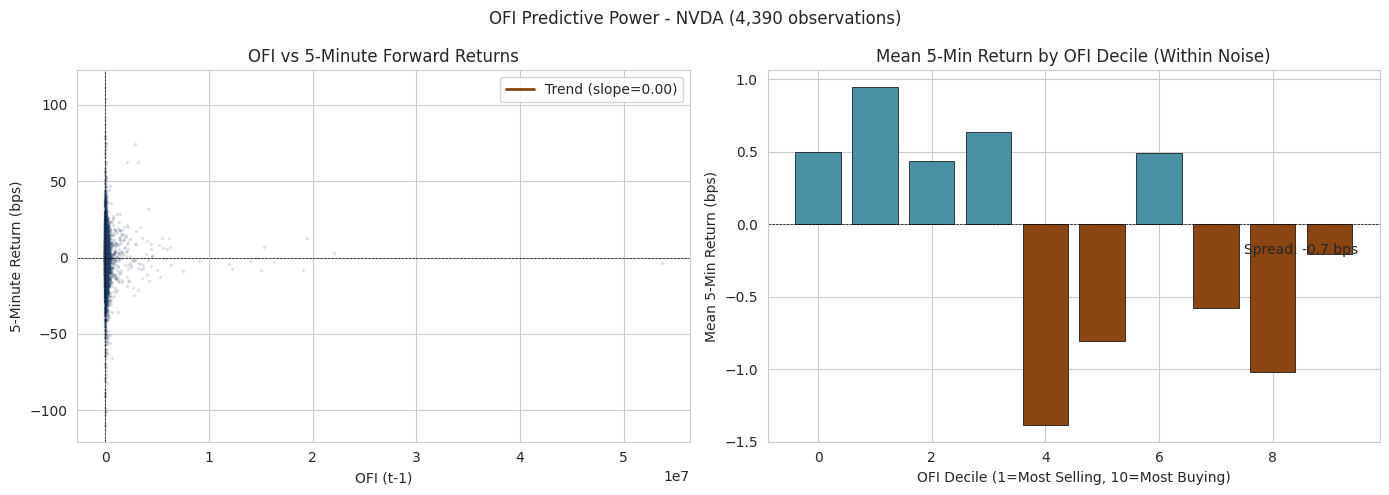

In [14]:
# Single cell so both panels (raw scatter + binned decile bars) render in
# one .ipynb output. Split-cell variants left the right panel empty under
# papermill's auto-display.
if multi_day is not None and len(multi_day) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Sample for scatter plot (too many points otherwise)
    sample = pdf.sample(min(10000, len(pdf)), random_state=42)

    # Left panel: scatter OFI vs 5-min return + trend
    axes[0].scatter(
        sample["ofi_lag1"],
        sample["markout_5"] * 10000,
        alpha=0.1,
        s=2,
        color=COLORS["blue"],
    )
    axes[0].set_xlabel("OFI (t-1)")
    axes[0].set_ylabel("5-Minute Return (bps)")
    axes[0].set_title("OFI vs 5-Minute Forward Returns")
    axes[0].axhline(0, color="black", linestyle="--", linewidth=0.5)
    axes[0].axvline(0, color="black", linestyle="--", linewidth=0.5)

    z = np.polyfit(sample["ofi_lag1"].dropna(), sample["markout_5"].dropna() * 10000, 1)
    p = np.poly1d(z)
    x_line = np.linspace(-1, 1, 100)
    axes[0].plot(
        x_line, p(x_line), color=COLORS["warm"], linewidth=2, label=f"Trend (slope={z[0]:.2f})"
    )
    axes[0].legend()

    # Right panel: binned decile analysis
    pdf["ofi_bin"] = pd.qcut(pdf["ofi_lag1"], q=10, labels=False, duplicates="drop")
    binned = pdf.groupby("ofi_bin")["markout_5"].mean() * 10000

    colors = [COLORS["warm"] if v < 0 else COLORS["accent"] for v in binned.values]
    axes[1].bar(range(len(binned)), binned.values, color=colors, edgecolor="black", linewidth=0.5)
    axes[1].set_xlabel("OFI Decile (1=Most Selling, 10=Most Buying)")
    axes[1].set_ylabel("Mean 5-Min Return (bps)")
    axes[1].set_title("Mean 5-Min Return by OFI Decile (Within Noise)")
    axes[1].axhline(0, color="black", linestyle="--", linewidth=0.5)

    spread = binned.iloc[-1] - binned.iloc[0]
    axes[1].annotate(
        f"Spread: {spread:.1f} bps",
        xy=(8.5, binned.iloc[-1]),
        fontsize=10,
        ha="center",
    )

    plt.suptitle(f"OFI Predictive Power - {SYMBOL} ({len(pdf):,} observations)", fontsize=12)
    plt.tight_layout()
    plt.show()

**The binned analysis shows no usable directional structure**:

- The decile means alternate sign, and the largest-magnitude bins are interior
  rather than at the extremes — there is no monotone ramp and no clean tail signal.
- The bottom (heavy-selling) decile mean is positive and the top (heavy-buying)
  decile mean is negative — the opposite of a momentum read.
- The top-minus-bottom spread is about −0.7 bps: slightly negative and, like the
  near-zero correlations above, within sampling noise of zero.

A decile spread that is within noise and on the order of round-trip execution
costs (~1–2 bps for liquid US equities) is the realistic baseline for a raw
microstructure signal at this horizon: there is no edge to harvest before costs,
let alone after them. The next panel makes the cost frictions explicit and shows
why even a marginally positive correlation would not convert to tradable P&L.

## 5. From Price Response to Tradable P&L: Three Markout Types

The correlation above is a *price-response* signal measured on the midpoint.
What a desk actually keeps is smaller, because two frictions sit between the
signal and the fill. We separate them with three markouts at each horizon:

- **Midpoint (p₂ − p₀)**: the raw price response — return of the quote
  midpoint from signal time to *h* bars ahead. This is the number the OFI
  correlation is built on, and the most generous reading of the edge.
- **Latency-adjusted (p₂ − p₁)**: the same midpoint return after a one-bar
  execution delay. The gap to the midpoint markout is the alpha that decays
  while the order is in flight.
- **Executable (bid/ask)**: a long pays the **ask** at decision time and
  exits at the **bid** *h* bars later. The gap to the midpoint markout is the
  spread the book charges — the friction §3.3 warns turns a statistical
  signal into negative trading P&L at sub-minute horizons.

Reading the three together shows where the edge goes: latency erodes it, and
the spread can erase it outright.

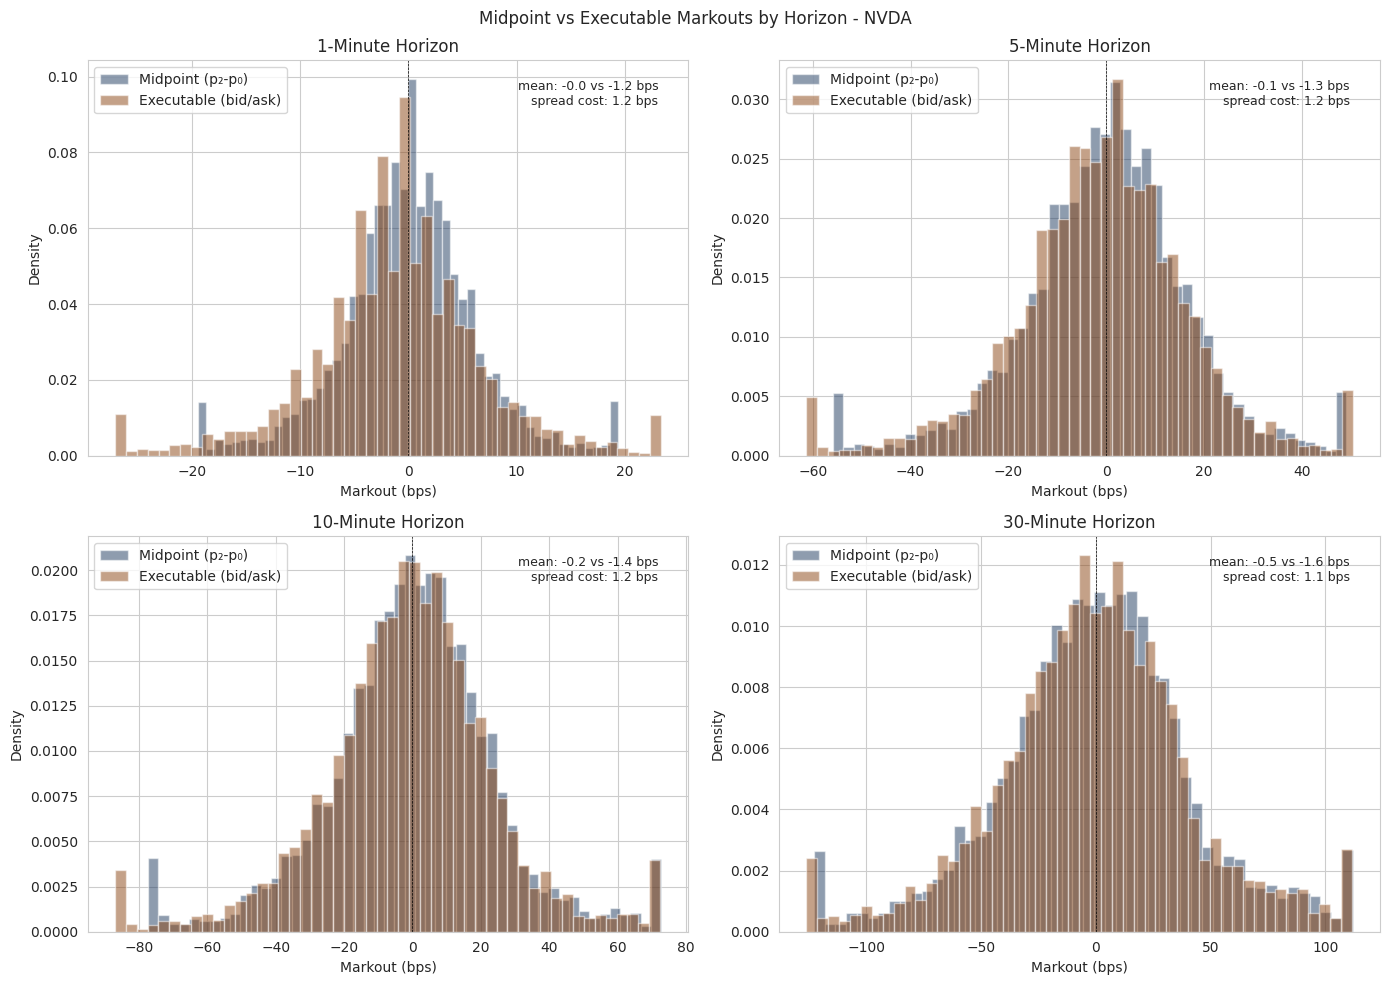

=== Mean markout by type (bps) ===
Horizon       Midpoint   Latency-adj    Executable
--------------------------------------------------
  1 min           -0.0           ≡ 0          -1.2
  5 min           -0.1          -0.1          -1.3
 10 min           -0.2          -0.2          -1.4
 30 min           -0.5          -0.5          -1.6


In [15]:
# Plot midpoint vs executable markout distributions across horizons, and
# summarize all three types (midpoint / latency-adjusted / executable).
if multi_day is not None and len(multi_day) > 0:
    summary_rows = []
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for i, h in enumerate([1, 5, 10, 30]):
        ax = axes[i // 2, i % 2]
        mid_col, adj_col, exec_col = f"markout_{h}", f"markout_{h}_adj", f"markout_{h}_exec"
        pdf_clean = multi_day.drop_nulls([mid_col, exec_col]).to_pandas()

        def _clip_bps(series):
            return series.clip(lower=series.quantile(0.01), upper=series.quantile(0.99)) * 10000

        ax.hist(
            _clip_bps(pdf_clean[mid_col]),
            bins=50,
            alpha=0.5,
            label="Midpoint (p₂-p₀)",
            color=COLORS["blue"],
            density=True,
        )
        ax.hist(
            _clip_bps(pdf_clean[exec_col]),
            bins=50,
            alpha=0.5,
            label="Executable (bid/ask)",
            color=COLORS["warm"],
            density=True,
        )
        ax.axvline(0, color="black", linestyle="--", linewidth=0.5)
        ax.set_xlabel("Markout (bps)")
        ax.set_ylabel("Density")
        ax.set_title(f"{h}-Minute Horizon")
        ax.legend()

        mid_mean = pdf_clean[mid_col].mean() * 10000
        exec_mean = pdf_clean[exec_col].mean() * 10000
        ax.annotate(
            f"mean: {mid_mean:+.1f} vs {exec_mean:+.1f} bps\nspread cost: {mid_mean - exec_mean:.1f} bps",
            xy=(0.95, 0.95),
            xycoords="axes fraction",
            ha="right",
            va="top",
            fontsize=9,
        )

        # Latency-adjusted markout is identically zero at h == LATENCY_BARS
        # (p₂ == p₁ by construction), so report its mean only past that horizon.
        adj_mean = (
            multi_day.drop_nulls([adj_col])[adj_col].mean() * 10000 if h > LATENCY_BARS else None
        )
        summary_rows.append((h, mid_mean, adj_mean, exec_mean))

    plt.suptitle(f"Midpoint vs Executable Markouts by Horizon - {SYMBOL}", fontsize=12)
    plt.tight_layout()
    plt.show()

    print("=== Mean markout by type (bps) ===")
    print(f"{'Horizon':<10}{'Midpoint':>12}{'Latency-adj':>14}{'Executable':>14}")
    print("-" * 50)
    for h, mid_mean, adj_mean, exec_mean in summary_rows:
        adj_str = f"{adj_mean:>14.1f}" if adj_mean is not None else f"{'≡ 0':>14}"
        print(f"{h:>3} min   {mid_mean:>12.1f}{adj_str}{exec_mean:>14.1f}")

**Key insights from the markout analysis**:

1. **Midpoint markout is the generous view**: it credits the signal with the
   full price response and ignores both execution delay and the spread.

2. **Latency erodes the edge**: a single bar of delay (p₂ − p₁) removes the
   fraction of the move that lands in the first minute — largest at short
   horizons, negligible by 30 minutes once total movement dominates.

3. **The spread can erase it**: paying the ask and exiting at the bid shifts
   the executable markout left of the midpoint markout by roughly one spread.
   At sub-minute horizons that gap routinely exceeds the signal itself, which
   is why a positive midpoint correlation is necessary but not sufficient for
   tradable P&L.

## 6. Save Results

Export the processed minute bars for use in downstream analysis.

In [16]:
if multi_day is not None and len(multi_day) > 0:
    output_file = OUTPUT_DIR / f"{SYMBOL}_minute_bars.parquet"
    multi_day.write_parquet(output_file)
    print(f"Saved: {output_file}")
    print(f"Shape: {multi_day.shape}")

Saved: 03_market_microstructure/output/databento/NVDA_minute_bars.parquet
Shape: (4500, 32)


## Key Takeaways

### 1. OFI ↔ Forward-Return Correlation

OFI has a positive correlation with forward returns ranging from ~0.002 at
the 1-minute horizon to ~0.02 at the 30-minute horizon. The sign is the
expected one — aggressive buying co-moves with subsequent positive returns
— but the per-observation magnitudes are small relative to the dispersion
of returns at the same horizons.

### 2. Horizon Dependence

The 1-5 minute correlations sit around 0.002-0.004 and the 30-minute
correlation around 0.02. This notebook does not separate that horizon
dependence into a permanent vs transient component; it reports the
unconditional correlation at each horizon.

### 3. Latency Matters

The difference between standard and latency-adjusted markouts shows that
execution speed is critical. Traders who can't act within 1 minute lose
a meaningful fraction of the available alpha.

### 4. Practical Alpha Is Limited

The top-minus-bottom OFI decile spread is about −0.7 bps on this slice — within
noise and on the order of round-trip transaction costs. There is no standalone
edge here: the decile means alternate sign with no tail structure, matching the
near-zero correlations. OFI is more useful as a **filter** (avoid trading against
strong flow) than as a primary alpha source, and any directional use would demand
far stronger, cost-aware evidence than this horizon provides.

### DataBento vs ITCH: When to Use Each

| Aspect | ITCH (Free) | DataBento (~$10/symbol/mo) |
|--------|-------------|----------------------------|
| Format | Binary, all NASDAQ stocks | Parquet, per-symbol |
| Preprocessing | Significant | Minimal |
| Multi-exchange | No | Yes |
| Best for | Learning, backtesting | Production, research |

---

**Next**: The notebooks in Chapter 8 build on these microstructure insights
to engineer alpha factors for machine learning models.